In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, classification_report,
    mean_squared_error, mean_absolute_error, r2_score,
)

pd.set_option("display.max_columns", 100)
print("Setup complete.")

Setup complete.


In [ ]:
from google.colab import files

print("Upload your TRAIN file:")
uploaded_train = files.upload()
train_filename = list(uploaded_train.keys())[0]

print("\nUpload your TEST file:")
uploaded_test = files.upload()
test_filename = list(uploaded_test.keys())[0]

train = pd.read_csv(train_filename)
test = pd.read_csv(test_filename)

print(f"\nTrain shape: {train.shape}")
print(f"Test shape: {test.shape}")


Upload your TRAIN file:


Saving traink.csv to traink.csv

Upload your TEST file:


Saving testk.csv to testk.csv

Train shape: (7651, 56)
Test shape: (1913, 55)


SHAPE: (7651, 56)

--- DTYPES ---
float64    53
int64       3
Name: count, dtype: int64

--- MISSING VALUES (top 15) ---
koi_bin_oedp_sig    1217
koi_max_mult_ev      926
koi_num_transits     926
koi_max_sngle_ev     926
koi_fwm_stat_sig     859
koi_fwm_prao         666
koi_fwm_pdeco        663
koi_dicco_mra        486
koi_dicco_msky       486
koi_dicco_mdec       486
koi_zmag             485
koi_dikco_mdec       465
koi_dikco_msky       465
koi_dikco_mra        465
koi_fwm_sra          427
dtype: int64

--- NUMERIC SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
row_id,7651.0,3.825000e+03,2208.797788,0.000000e+00,1.912500e+03,3.825000e+03,5.737500e+03,7.650000e+03
koi_period,7651.0,7.896689e+01,1490.984000,2.418425e-01,2.718871e+00,9.767859e+00,4.047883e+01,1.299958e+05
koi_time0bk,7651.0,1.660980e+02,66.184027,1.205159e+02,1.327806e+02,1.372604e+02,1.708836e+02,9.070447e+02
koi_time0,7651.0,2.454999e+06,66.184026,2.454954e+06,2.454966e+06,2.454970e+06,2.455004e+06,2.455740e+06
koi_eccen,7355.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
koi_impact,7355.0,6.965488e-01,2.931753,0.000000e+00,1.950000e-01,5.320000e-01,8.840000e-01,1.008060e+02
koi_duration,7651.0,5.523269e+00,6.139249,5.200000e-02,2.429945e+00,3.748000e+00,6.190000e+00,9.001000e+01
koi_depth,7355.0,2.353781e+04,80133.724142,0.000000e+00,1.583500e+02,4.177000e+02,1.454250e+03,9.216700e+05
koi_ror,7355.0,2.473382e-01,2.889203,1.289000e-03,1.231150e-02,2.097400e-02,8.787450e-02,9.987065e+01
koi_srho,7390.0,9.164282e+00,53.963863,4.000000e-05,2.353600e-01,9.724650e-01,2.944000e+00,9.808542e+02



--- TARGET: target ---
Unique values: 2
Looks like CLASSIFICATION. Value counts:
target
0    3871
1    3780
Name: count, dtype: int64


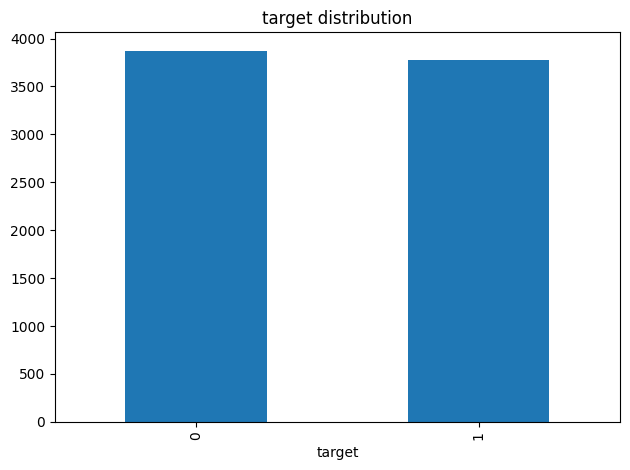


>>> Detected task type: classification

ID column 'row_id': 7651 unique / 7651 rows

--- DUPLICATE ROWS: 0 ---


In [ ]:
TARGET = "target"
ID_COL = "row_id"


print(f"SHAPE: {train.shape}")


print("\n--- DTYPES ---")
print(train.dtypes.value_counts())

print("\n--- MISSING VALUES (top 15) ---")
miss = train.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]
print(miss.head(15) if len(miss) else "No missing values.")

print("\n--- NUMERIC SUMMARY ---")
display(train.describe().T.head(15))

if TARGET in train.columns:
    n_unique = train[TARGET].nunique()
    print(f"\n--- TARGET: {TARGET} ---")
    print(f"Unique values: {n_unique}")

    if n_unique <= 20:
        TASK = "classification"
        print("Looks like CLASSIFICATION. Value counts:")
        print(train[TARGET].value_counts())
        train[TARGET].value_counts().plot(kind="bar", title=f"{TARGET} distribution")
    else:
        TASK = "regression"
        print("Looks like REGRESSION. Stats:")
        print(train[TARGET].describe())
        train[TARGET].hist(bins=40)
        plt.title(f"{TARGET} distribution")
    plt.tight_layout()
    plt.show()

    print(f"\n>>> Detected task type: {TASK}")

    if TASK == "regression":
        num_df = train.select_dtypes(include=[np.number])
        corr = num_df.corr()[TARGET].abs().sort_values(ascending=False)
        print("\nTop correlated features with target:")
        print(corr.head(11)[1:])

if ID_COL and ID_COL in train.columns:
    print(f"\nID column '{ID_COL}': {train[ID_COL].nunique()} unique / {len(train)} rows")

print("\n--- DUPLICATE ROWS:", train.duplicated().sum(), "---")


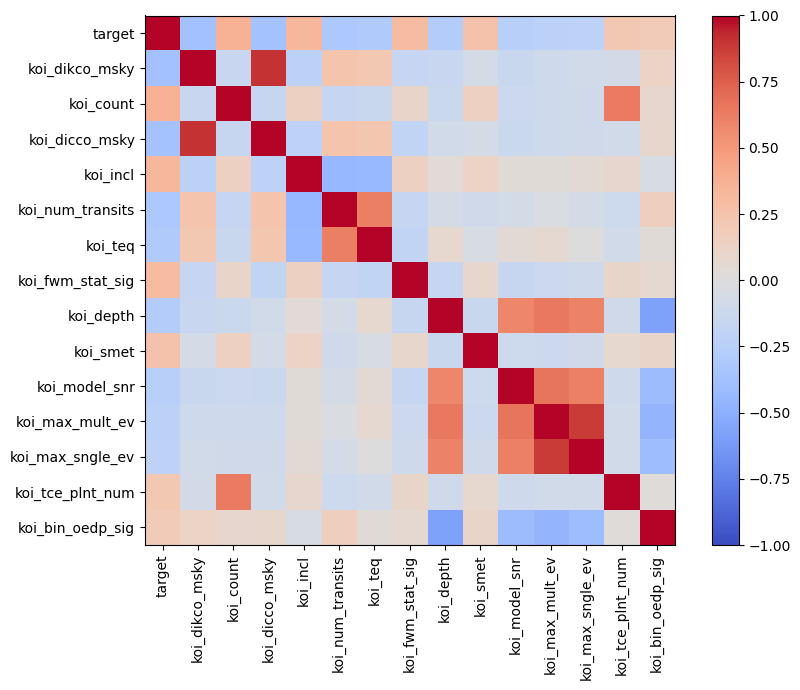

In [ ]:
num_df = train.select_dtypes(include=[np.number])
if TARGET in num_df.columns:
    top_cols = num_df.corr()[TARGET].abs().sort_values(ascending=False).head(15).index
else:
    top_cols = num_df.columns[:15]

corr = num_df[top_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(top_cols)))
ax.set_yticks(range(len(top_cols)))
ax.set_xticklabels(top_cols, rotation=90)
ax.set_yticklabels(top_cols)
fig.colorbar(im)
plt.tight_layout()
plt.show()


In [ ]:
def build_preprocessor(X):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    pre = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ])
    return pre

drop_cols = [c for c in [ID_COL, TARGET] if c]
X = train.drop(columns=drop_cols)
y = train[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if TASK == "classification" and y.nunique() < 20 else None,
)

preprocessor = build_preprocessor(X)
print("Preprocessor ready.")
if TASK == "classification":
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    }

    best_name, best_score, best_pipe = None, -np.inf, None

    for name, clf in models.items():
        pipe = Pipeline([("pre", preprocessor), ("clf", clf)])
        pipe.fit(X_train, y_train)

        val_pred = pipe.predict(X_val)
        acc = accuracy_score(y_val, val_pred)
        f1 = f1_score(y_val, val_pred, average="weighted")
        try:
            proba = pipe.predict_proba(X_val)
            auc = roc_auc_score(y_val, proba[:, 1]) if proba.shape[1] == 2 else roc_auc_score(y_val, proba, multi_class="ovr")
        except Exception:
            auc = None

        print(f"\n=== {name} ===")
        print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}" + (f" | ROC-AUC: {auc:.4f}" if auc else ""))
        print(classification_report(y_val, val_pred))

        score = auc if auc is not None else acc
        if score > best_score:
            best_name, best_score, best_pipe = name, score, pipe

    print(f"\n>>> Best model: {best_name} (score={best_score:.4f})")

    final_model = Pipeline([("pre", preprocessor), ("clf", models[best_name])])
    final_model.fit(X, y)

Preprocessor ready.

=== LogisticRegression ===
Accuracy: 0.8465 | F1: 0.8464 | ROC-AUC: 0.9238
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       775
           1       0.82      0.88      0.85       756

    accuracy                           0.85      1531
   macro avg       0.85      0.85      0.85      1531
weighted avg       0.85      0.85      0.85      1531


=== RandomForest ===
Accuracy: 0.8988 | F1: 0.8987 | ROC-AUC: 0.9604
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       775
           1       0.91      0.88      0.90       756

    accuracy                           0.90      1531
   macro avg       0.90      0.90      0.90      1531
weighted avg       0.90      0.90      0.90      1531


>>> Best model: RandomForest (score=0.9604)


In [ ]:

drop_cols_test = [c for c in [ID_COL, TARGET] if c and c in test.columns]
X_test = test.drop(columns=drop_cols_test)


if TASK == "classification":
    preds = final_model.predict(X_test)
else:
    preds = final_model.predict(X_test)

submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: preds
})


submission.to_csv("sample_submission.csv", index=False)

print(f"Saved {len(submission)} rows to sample_submission.csv")
print(submission.head())


from google.colab import files
files.download("sample_submission.csv")

Saved 1913 rows to sample_submission.csv
   row_id  target
0       0       0
1       1       1
2       2       1
3       3       1
4       4       1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

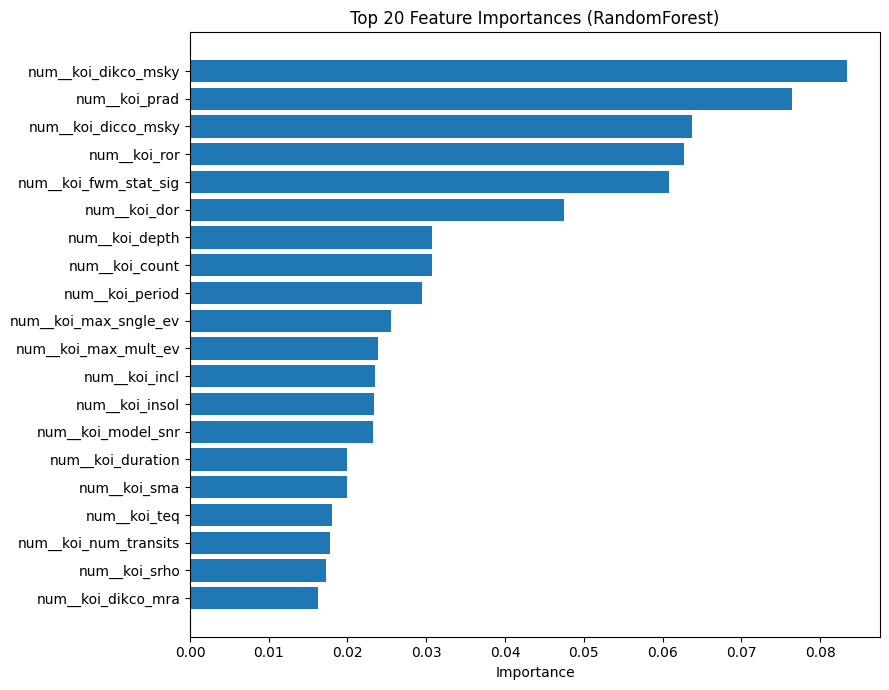

<Figure size 640x480 with 0 Axes>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

                  feature  importance
53    num__koi_dikco_msky    0.083436
9           num__koi_prad    0.076441
50    num__koi_dicco_msky    0.063690
7            num__koi_ror    0.062727
41  num__koi_fwm_stat_sig    0.060833
14           num__koi_dor    0.047540
6          num__koi_depth    0.030715
22         num__koi_count    0.030679
0         num__koi_period    0.029506
19  num__koi_max_sngle_ev    0.025566
20   num__koi_max_mult_ev    0.023912
11          num__koi_incl    0.023548
13         num__koi_insol    0.023329
21     num__koi_model_snr    0.023265
5       num__koi_duration    0.019955
10           num__koi_sma    0.019915
12           num__koi_teq    0.018025
23  num__koi_num_transits    0.017834
8           num__koi_srho    0.017225
51     num__koi_dikco_mra    0.016279


In [13]:

feature_names = final_model.named_steps["pre"].get_feature_names_out()
clf = final_model.named_steps["clf"]

if hasattr(clf, "feature_importances_"):

    importances = clf.feature_importances_
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

elif hasattr(clf, "coef_"):

    coefs = clf.coef_
    if coefs.ndim > 1:
        coefs = np.abs(coefs).mean(axis=0)
    else:
        coefs = np.abs(coefs)
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": coefs
    }).sort_values("importance", ascending=False)

else:
    raise ValueError("Model has neither feature_importances_ nor coef_.")


top_n = 20
top_imp = imp_df.head(top_n)

plt.figure(figsize=(9, 7))
plt.barh(top_imp["feature"][::-1], top_imp["importance"][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances ({best_name})")
plt.tight_layout()
plt.show()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("feature_importance.png")

print(imp_df.head(20))